Found 4 CSV files. Generating PNG chart...
Aviso: O arquivo 'INOMMUS.csv' não está no LEGEND_MAP. Usando nome automático.
Aviso: O arquivo 'Maskable DARSPPO.csv' não está no LEGEND_MAP. Usando nome automático.
Aviso: O arquivo 'Maskable Hephaestus.csv' não está no LEGEND_MAP. Usando nome automático.
Aviso: O arquivo 'Maskable INOMMUS.csv' não está no LEGEND_MAP. Usando nome automático.


/tmp/ipykernel_1636889/2350251311.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(csv_files))



Success! Static chart saved to: '/home/david/projects/multi-user-sfc/rl_saved_models/plots/reward_comparison_chart.png'


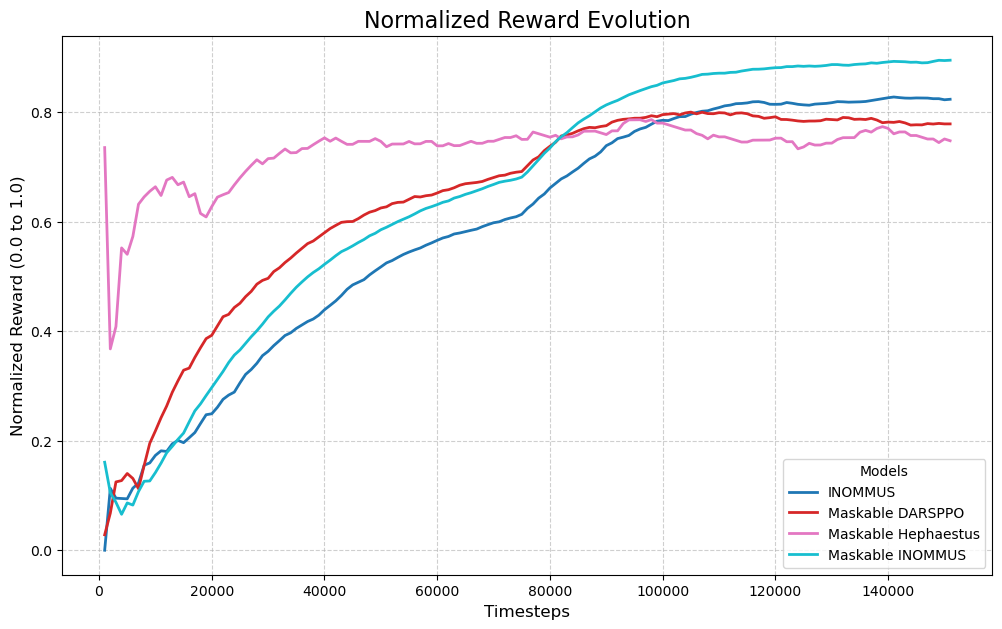

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import numpy as np

# --- CONFIGURAÇÕES DO GRÁFICO ---

# (NOVO) Ative para normalizar todas as recompensas entre 0 e 1
# Isso é útil se cada modelo tem uma "escala" de recompensa diferente.
ENABLE_NORMALIZATION = True

# Defina o tamanho da "janela" para a média móvel.
SMOOTHING_WINDOW = 75
# -----------------------------------


def plot_rewards_png(csv_folder, output_png_file="reward_comparison_chart.png"):
    """
    Lê todos os arquivos CSV de uma pasta e plota um gráfico de linha estático (PNG)
    da recompensa, opcionalmente normalizando e suavizando as curvas.
    """

    # --- MAPEAMENTO DA LEGENDA ---
    # Mapeia nomes de arquivos para nomes "limpos" na legenda
    LEGEND_MAP = {
        # Modelos PPO Padrão
        "Ppo darsppo allocation 0.csv": "DARSPPO",
        "Ppo hephaestus allocation 0.csv": "Hephaestus",
        "Ppo sfc allocation 0.csv": "INOMMUS",  # Assumindo que sfc=INOMMUS
        # Modelos Maskable PPO
        "Maskableppo darsppo allocation 0.csv": "Maskable DARSPPO",
        "Maskableppo hephaestus allocation 0.csv": "Maskable Hephaestus",
        "Maskableppo sfc allocation 0.csv": "Maskable INOMMUS",  # Assumindo que sfc=INOMMUS
    }
    # ------------------------------------------

    # 1. Encontrar todos os arquivos CSV
    search_pattern = os.path.join(csv_folder, "*.csv")
    csv_files = glob.glob(search_pattern)

    if not csv_files:
        print(f"Error: No .csv files found in folder '{csv_folder}'")
        return

    print(f"Found {len(csv_files)} CSV files. Generating PNG chart...")

    # 2. Inicializar a figura
    plt.figure(figsize=(12, 7))
    ax = plt.gca()
    colors = plt.cm.get_cmap("tab10", len(csv_files))

    y_axis_label = "Mean Reward"  # Padrão

    # 3. Iterar sobre cada arquivo CSV
    for i, csv_file in enumerate(csv_files):
        try:
            df = pd.read_csv(csv_file)

            # 3.1. Definir nome da legenda
            basename = os.path.basename(csv_file)
            model_name = LEGEND_MAP.get(basename)
            if model_name is None:
                print(
                    f"Aviso: O arquivo '{basename}' não está no LEGEND_MAP. Usando nome automático."
                )
                model_name = basename.replace(".csv", "").replace("_", " ").capitalize()

            line_color = colors(i)

            # 3.2. Ler dados
            timesteps = df["Step"]
            reward_data_raw = df["Value"]

            # 3.3. (NOVO) Normalizar dados se ativado
            if ENABLE_NORMALIZATION:
                min_reward = reward_data_raw.min()
                max_reward = reward_data_raw.max()

                # Evita divisão por zero se a recompensa for constante (improvável)
                if (max_reward - min_reward) == 0:
                    reward_to_plot_raw = reward_data_raw - min_reward
                else:
                    # Aplica a normalização Min-Max (escala 0 a 1)
                    reward_to_plot_raw = (reward_data_raw - min_reward) / (max_reward - min_reward)

                y_axis_label = "Normalized Reward (0.0 to 1.0)"
            else:
                reward_to_plot_raw = reward_data_raw
                y_axis_label = "Mean Reward"

            # 3.4. Aplicar suavização (média móvel)
            # A suavização é aplicada *depois* da normalização
            reward_to_plot_smoothed = reward_to_plot_raw.rolling(
                window=SMOOTHING_WINDOW, min_periods=1
            ).mean()

            # 4. Plotar a linha principal (SUAVIZADA)
            ax.plot(
                timesteps,
                reward_to_plot_smoothed,
                color=line_color,
                label=model_name,
                linewidth=2.0,
            )

            # 5. Plotar a linha original (instável) no fundo
            # ax.plot(timesteps, reward_to_plot_raw, color=line_color, alpha=0.25, linewidth=0.5)

        except Exception as e:
            print(f"Error processing file '{csv_file}': {e}")
            print("Check if 'Step' and 'Value' columns exist.")
            continue

    # 6. Configurar o layout do gráfico
    if ENABLE_NORMALIZATION:
        ax.set_title("Normalized Reward Evolution", fontsize=16)
    else:
        ax.set_title("Mean Reward Evolution ", fontsize=16)

    ax.set_xlabel("Timesteps", fontsize=12)
    ax.set_ylabel(y_axis_label, fontsize=12)

    # Adiciona a legenda
    ax.legend(title="Models", loc="best", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)

    # 7. Salvar o gráfico como um arquivo PNG
    try:
        plt.savefig(output_png_file, dpi=300, bbox_inches="tight")
        print(f"\nSuccess! Static chart saved to: '{os.path.abspath(output_png_file)}'")
    except Exception as e:
        print(f"\nError saving PNG file: {e}")


# --- Bloco para executar o script diretamente ---
if __name__ == "__main__":
    # pip install matplotlib pandas

    CSV_FOLDER = "csv_resultados"
    os.makedirs(CSV_FOLDER, exist_ok=True)

    # (Opcional: Bloco de teste com os nomes de arquivo do seu gráfico)
    if not glob.glob(os.path.join(CSV_FOLDER, "*.csv")):
        print(f"Criando CSVs de exemplo em '{CSV_FOLDER}'...")
        steps = np.arange(1000, 40001, 1000)

        # Simula dados para cada arquivo
        d1 = {
            "Wall time": 0,
            "Step": steps,
            "Value": -50 * np.exp(-steps / 10000) + np.random.normal(0, 5, len(steps)),
        }
        pd.DataFrame(d1).to_csv(
            os.path.join(CSV_FOLDER, "Ppo darsppo allocation 0.csv"), index=False
        )

        d2 = {
            "Wall time": 0,
            "Step": steps,
            "Value": -60 * np.exp(-steps / 5000) + 10 + np.random.normal(0, 3, len(steps)),
        }
        pd.DataFrame(d2).to_csv(
            os.path.join(CSV_FOLDER, "Maskableppo hephaestus allocation 0.csv"), index=False
        )

        d3 = {
            "Wall time": 0,
            "Step": steps,
            "Value": -150 * np.exp(-steps / 8000) + np.random.normal(0, 8, len(steps)),
        }
        pd.DataFrame(d3).to_csv(
            os.path.join(CSV_FOLDER, "Maskableppo sfc allocation 0.csv"), index=False
        )

    # Chama a função principal
    plot_rewards_png(CSV_FOLDER)